# VEP Analysis

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.utils as utils
import src.clinvar as cv

In [2]:
### Attempts to add new slots to the xarray dataset ###

# import xarray as xr

# xr_ds = xr.open_dataset(xr_ds_path, mode="a-")

# new_slots=  np.append(xr_ds.coords["slot"].data, "delta_pow2_mean")
# print(new_slots)
# xr_ds["flashzoi"].assign_coords({"slot": ("slot", new_slots)})

## Import non-null VEP results

In [ ]:
import xarray as xr
xr_ds_path = os.path.join(os.path.expanduser('~'),"projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv_test/chrX.zarr")

xr_ds = xr.open_dataset(xr_ds_path)

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [4]:
xr_ds_path = os.path.join(os.path.expanduser('~'),"projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv_test/chrX.zarr")

vep_df = vp.load_vep_results(xr_ds_path=xr_ds_path, 
                             dropna_subset=["flashzoi"])
vep_df.head()

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


Contents of xarray after filtering [filled values / total values]:
 - rows: 2431746
 - sites: 53 / 438
 - samples: 2549 / 2549
 - ploid: 2 / 2
 - slots: 9 / 13


,site,sample,ploid,slot,evo2_40b,dnabert2,spliceai,evo2_7b,flashzoi,evo2_40b_base,spliceai_mm,evo2_7b_base
1921949,chrX:10233677-10233678_T_C,REF,0,delta_abs_mean,NaN,NaN,NaN,NaN,0.000539,NaN,NaN,NaN
1921950,chrX:10233677-10233678_T_C,REF,0,delta_max_max,NaN,NaN,NaN,NaN,0.254574,NaN,NaN,NaN
1921951,chrX:10233677-10233678_T_C,REF,0,delta_mean,NaN,NaN,NaN,NaN,-0.000212,NaN,NaN,NaN
1921952,chrX:10233677-10233678_T_C,REF,0,delta_pow2_mean,NaN,NaN,NaN,NaN,0.000008,NaN,NaN,NaN
1921953,chrX:10233677-10233678_T_C,REF,0,len_seq_mut,NaN,NaN,NaN,NaN,262144.000000,NaN,NaN,NaN


## Estimate total time

Based on the existing results, estimate how long it will take to run all selected ClinVar variants. 

In [5]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 
va.estimate_runtime(vep_df,
                     total_sites=bed_utr["name"].n_unique(),
                     model_name="flashzoi",
                     time_col="time_total",
                     n_gpus=1)

3.30 minutes per site
Number of days it should take to run all 13771 sites genome-wide:
31.52


Count the number of samples per site (should be all identical). 

In [6]:
vep_df.groupby("site")["sample"].nunique().describe()

count      53.0
mean     2549.0
std         0.0
min      2549.0
25%      2549.0
50%      2549.0
75%      2549.0
max      2549.0
Name: sample, dtype: float64

In [7]:
vep_df.groupby("slot")["flashzoi"].describe()

,count,mean,std,min,25%,50%,75%,max
slot,,,,,,,,
delta_abs_mean,270194.0,0.000830,0.001142,0.000000,0.000260,0.000443,0.000895,0.009696
delta_max_max,270194.0,0.987355,2.038990,0.000000,0.283476,0.548257,0.859001,14.798325
delta_mean,270194.0,-0.000078,0.000839,-0.006743,-0.000141,-0.000014,0.000126,0.002379
delta_pow2_mean,270194.0,0.000061,0.000174,0.000000,0.000002,0.000006,0.000027,0.001160
len_seq_mut,270194.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
len_seq_wt,270194.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
output_length,270194.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
time_run_vep,270194.0,0.038436,0.000780,0.035142,0.038331,0.038536,0.038650,0.073299
time_total,270194.0,0.038786,0.000811,0.035604,0.038685,0.038827,0.039061,0.073751


Plot a sampling of the various slot values, including different VEP metrics and metadata about how long each iteration took to run.

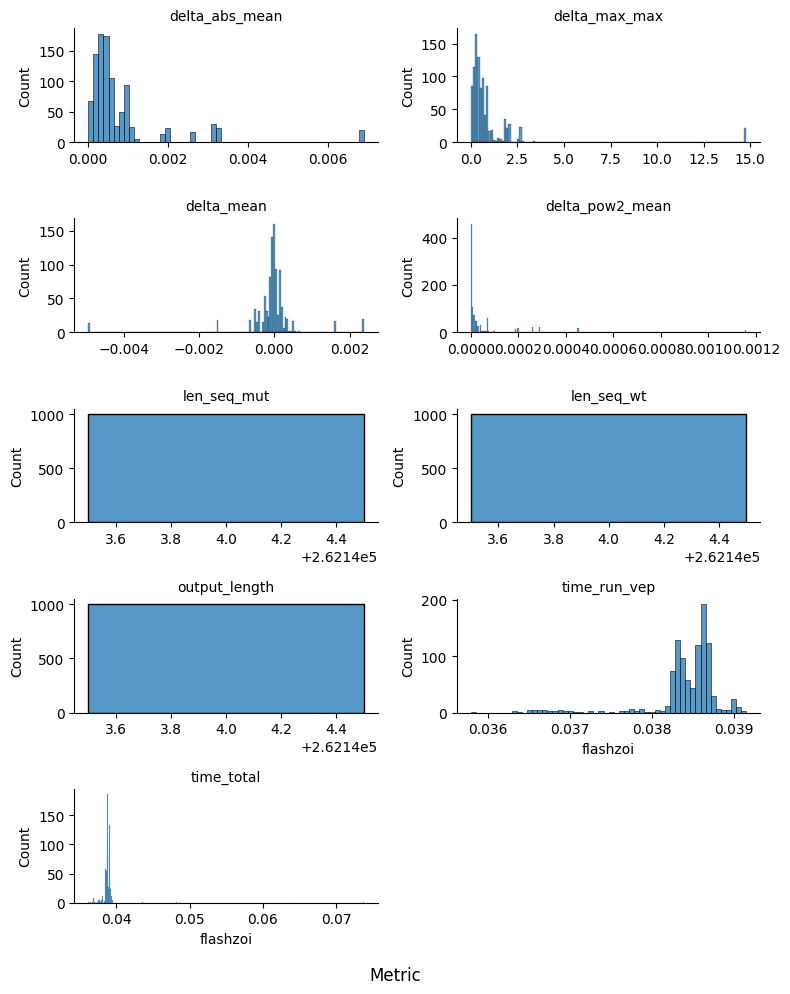

In [8]:
def summary_histograms(vep_df,
                       slot_col="slot", 
                       x="flashzoi",
                       height=2,
                       aspect=2, 
                       col_wrap=2,
                       margin_titles=True,
                       sharex=False,
                       sharey=False, 
                       sample_size=1000):

    # Create a figure with subplots for each slot
    g = sns.FacetGrid(vep_df.groupby(slot_col).sample(sample_size).sort_values(slot_col),
                    col=slot_col,  # Changed from row to col
                    col_wrap=col_wrap,  # Added col_wrap to wrap facets
                    height=height, 
                    aspect=aspect, 
                    margin_titles=margin_titles,
                    sharex=sharex, 
                    sharey=sharey)
    g.map_dataframe(sns.histplot, x=x)
    g.set_titles("{col_name}")
    g.fig.supxlabel("Metric")
    plt.tight_layout()

summary_histograms(vep_df)


## Annotate VEP results with variant metadata

In [9]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 

print("bed shape:",bed_utr.shape)
print("vep_df shape:",vep_df.shape)

print(bed_utr["CLNSIG"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_simple"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_super_simple"].value_counts().sort(by="count", descending=True))

bed shape: (13771, 25)
vep_df shape: (2431746, 12)
shape: (9, 2)
┌─────────────────────────────────┬───────┐
│ CLNSIG                          ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Benign                          ┆ 8029  │
│ Likely_benign                   ┆ 1851  │
│ Benign/Likely_benign            ┆ 1836  │
│ Pathogenic/Likely_pathogenic    ┆ 917   │
│ Pathogenic                      ┆ 846   │
│ Likely_pathogenic               ┆ 288   │
│ Pathogenic/Likely_pathogenic/P… ┆ 2     │
│ Benign|other                    ┆ 1     │
│ Benign|confers_sensitivity      ┆ 1     │
└─────────────────────────────────┴───────┘
shape: (4, 2)
┌───────────────┬───────┐
│ CLNSIG_simple ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ benign        ┆ 8031  │
│ likely_benign ┆ 3687  │
│ likely_path   ┆ 1207  │
│ path          ┆ 846   │
└───────────────┴───────┘
s

In [10]:
vep_df2 = vep_df.merge(bed_utr.to_pandas(), 
                       left_on="site", 
                       right_on="name")

print("Merged vep_df/bed shape:",vep_df2.shape)
print("\n",vep_df2["CLNSIG"].value_counts().sort_values(ascending=False))
print("\n",vep_df2["CLNSIG_simple"].value_counts().sort_values(ascending=False))
print("\n",vep_df2["CLNSIG_super_simple"].value_counts().sort_values(ascending=False))

Merged vep_df/bed shape: (2431746, 37)

 CLNSIG
Benign                          1468224
Pathogenic                       321174
Likely_benign                    229410
Pathogenic/Likely_pathogenic     183528
Benign/Likely_benign             183528
Likely_pathogenic                 45882
Name: count, dtype: int64

 CLNSIG_simple
benign           1468224
likely_benign     412938
path              321174
likely_path       229410
Name: count, dtype: int64

 CLNSIG_super_simple
benign    1881162
path       550584
Name: count, dtype: int64


Preprocess VEP data and add normalized column. 

In [11]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, Normalizer
# scaler = MinMaxScaler()
scaler = RobustScaler()
# scaler = Normalizer()

delta_df = vep_df2.loc[vep_df2["slot"].str.startswith("delta_")].copy()

# Group by site and slot, then apply minmax scaling
delta_df.loc[:,"flashzoi_norm"] = delta_df.groupby(["GENE","slot"])["flashzoi"].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel() if len(x) > 0 else 0
)

 # Sort by scoring strategy
clinsig_col="CLNSIG_simple"
delta_df = utils.sort_by_reverse_string(delta_df, 
                                        column='slot',
                                        extra_sort_cols=[clinsig_col],
                                        ascending=[True, False])

In [12]:
delta_df.loc[delta_df["CLNSIG_simple"]=="path"]["flashzoi_norm"].describe()

count    1.427440e+05
mean    -5.209639e+01
std      1.392977e+04
min     -3.721426e+06
25%     -1.604530e-01
50%      0.000000e+00
75%      8.395467e-01
max      5.206490e+00
Name: flashzoi_norm, dtype: float64

In [19]:
def plot_violin(df,
                x="CLNSIG_simple",
                y="flashzoi",
                hue="CLNSIG_simple",
                row=None,#"GENE",
                col="slot",
                palette=utils.get_clinsig_palette(),
                cut=0,
                height=3,
                aspect=1,
                sharey=False,
                sharex=True):
    # Filter for delta metrics and create violin plot with facets

    g = sns.FacetGrid(df, 
                    row=row, 
                    col=col,
                    height=height, 
                    aspect=aspect, 
                    sharey=sharey, 
                    sharex=sharex, 
                    margin_titles=True)
    g.map_dataframe(sns.violinplot, 
                    x=x, 
                    y=y, 
                    hue=hue,
                    palette=palette,
                    cut=cut
                    )
    g.fig.suptitle(va.summarise_title(df)+"\n"+ va.summarise_sites(df), y=1.02)
    g.set_titles(row_template="{row_name}", col_template=
                 "{col_name}")
    for ax in g.axes.flat:
        plt.setp(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

def plot_kde(df,
             x="flashzoi",
             hue="CLNSIG_simple",
             row="slot",
             col=None, 
             height=3,
             aspect=2,
             alpha=.75,
             fill=True,
             legend=True, 
             sharey=False,
             sharex=False):
    # Filter for delta metrics and create 2D density plot with facets

    g = sns.FacetGrid(df, 
                    row=row, 
                    col=col,
                    height=height, 
                    aspect=aspect, 
                    sharey=sharey, 
                    sharex=sharex)
    g.map_dataframe(sns.kdeplot, 
                    x=x, 
                    hue=hue,
                    palette=utils.get_clinsig_palette(),
                    alpha=alpha,
                    fill=fill,  # Fill the KDE plot
                    legend=legend)
    g.set_titles("{row_name}")
    g.fig.suptitle(va.summarise_title(df)+"\n"+ va.summarise_sites(df), y=1.02)
    plt.tight_layout()

    # Add legend with explicit legend handles
    handles, labels = g.axes[0,0].get_legend_handles_labels()
    g.fig.legend(handles, labels, title="Clinical Significance", 
                bbox_to_anchor=(1.05, 0.5), loc='center left')
    plt.show()
    

Violin plot

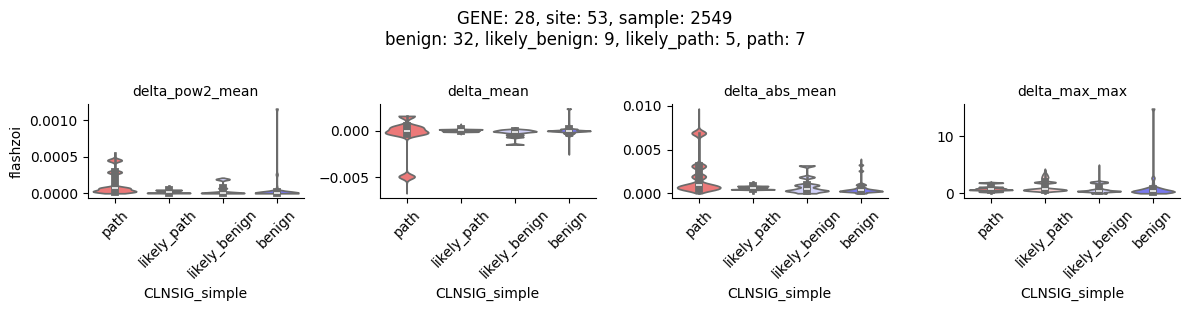

In [15]:
plot_violin(delta_df)

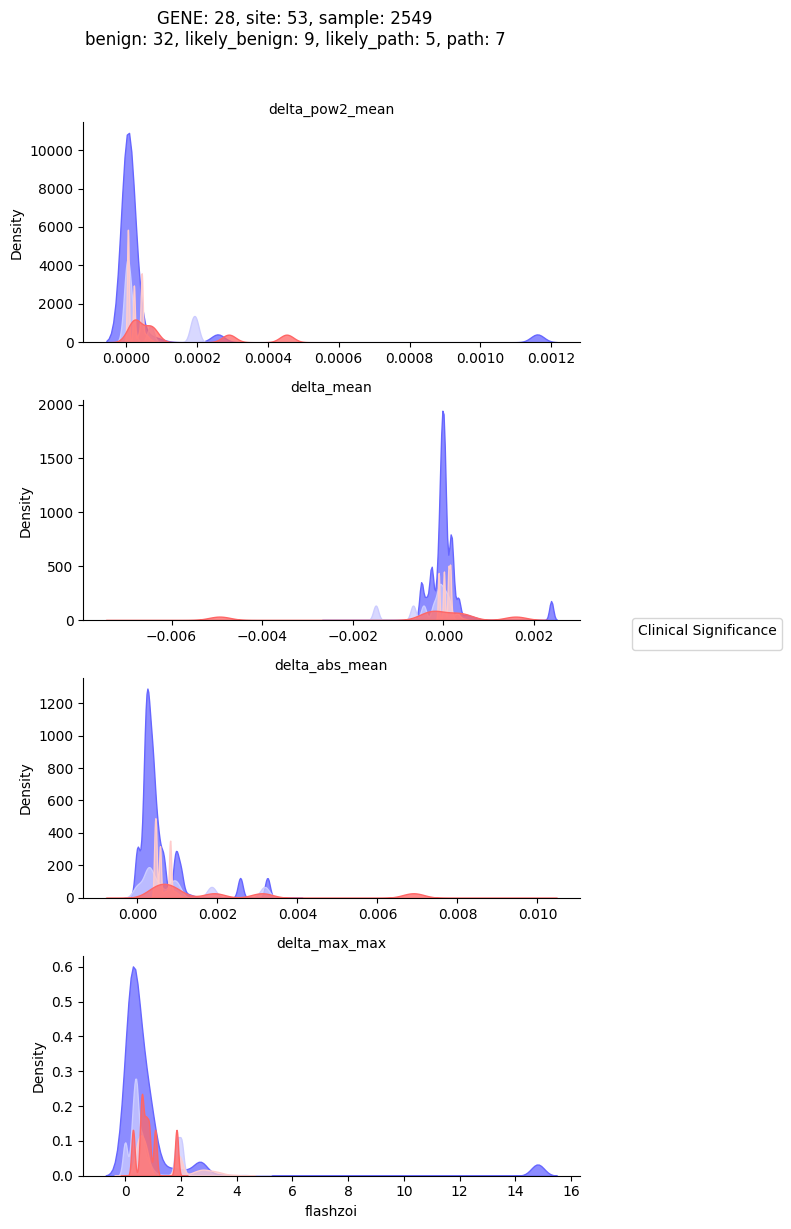

In [16]:
plot_kde(delta_df)

In [20]:
clnsig_simple_counts = delta_df.groupby("GENE")["CLNSIG_super_simple"].nunique().sort_values(ascending=False)
clnsig_simple_counts = clnsig_simple_counts.loc[clnsig_simple_counts>1]
clnsig_simple_counts

GENE
DMD      2
CLCN4    2
SHOX     2
OFD1     2
Name: CLNSIG_super_simple, dtype: int64

In [27]:
bed_utr.filter(pl.col("CLNSIG").str.to_lowercase().str.contains("conflict"))

chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,CLNREVSTAT_score,CLNSIG_simple,CLNSIG_super_simple,GENE
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,i64,str,str,str


/home/schilder/projects/VEP_DNA/src/vep_analysis.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vep_df['gene_site'] = vep_df[gene_col] + '_' + vep_df[site_col]


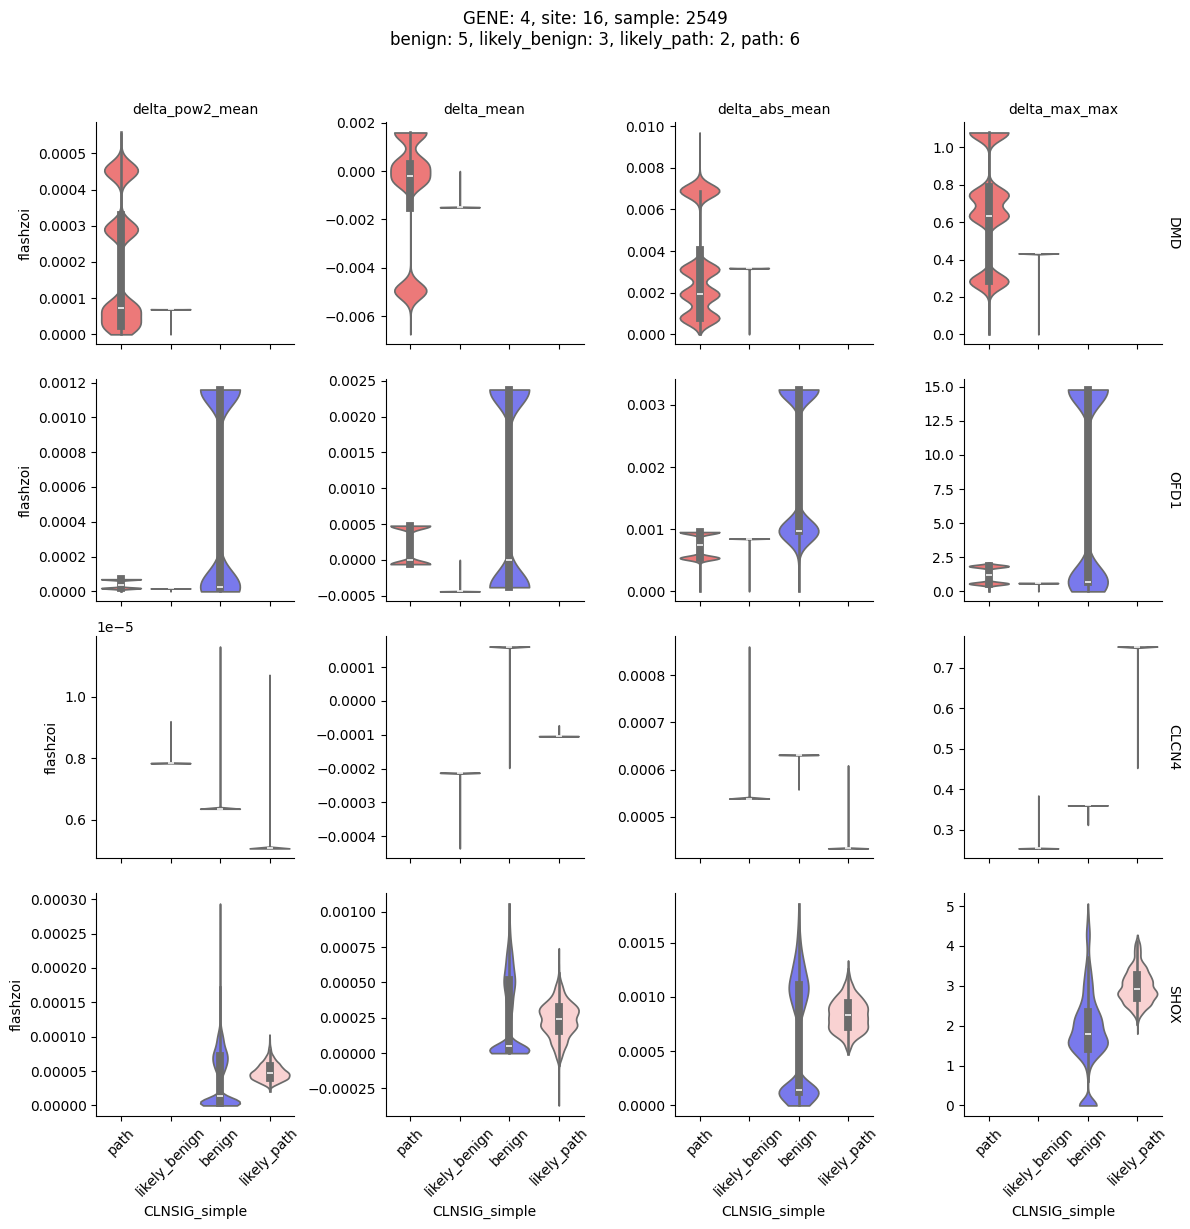

In [21]:
vep_select = delta_df.loc[delta_df["GENE"].isin(clnsig_simple_counts.index)]

g = plot_violin(vep_select, row="GENE")
